# Requisitos:
- Crear cuenta en https://wandb.ai/
- Ejecutar `wandb login` antes de correr las celdas
- Los resultados se guardan en el proyecto "speech-commands-model-a"

## Conversión de Audio a Mel-Spectrogramas en GPU

Este bloque procesa todos los archivos `.wav` de la carpeta `archive` y sus subdirectorios (clases), convirtiéndolos a imágenes mel-espectrogram que se guardan en `archive_img` con la misma estructura de carpetas pero con sufijo `_img`.

In [ ]:
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Encontrar la carpeta raíz del proyecto
def find_project_root(start: Path) -> Path:
    """Busca hacia arriba la carpeta que contiene `src` y `settings.gradle.kts`."""
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "settings.gradle.kts").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")

project_root = find_project_root(Path.cwd()).resolve()
source_root = project_root / "modelos" / "archive"
target_root = project_root / "modelos" / "archive_img"

print(f"Origen: {source_root}")
print(f"Destino: {target_root}")

# Validar carpetas
if not source_root.exists() or not target_root.exists():
    raise FileNotFoundError(f"No se encontraron las carpetas esperadas")

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}\n")

# Mel-Spectrogram en GPU
mel_transform = T.MelSpectrogram(
    sample_rate=16000, n_fft=1024, hop_length=256, n_mels=128
).to(device)

def load_wav_as_tensor(audio_path: Path):
    """Carga WAV sin dependencias problemáticas."""
    sr, data = wavfile.read(str(audio_path))
    if data.dtype.kind in {"i", "u"}:
        max_val = float(max(abs(data.min()), abs(data.max()), 1))
        data = data.astype("float32") / max_val
    else:
        data = data.astype("float32")
    if data.ndim == 1:
        data = data[None, :]
    else:
        data = data.T
    return torch.from_numpy(data), sr

def norm_to_uint8(arr):
    """Normaliza array a uint8 para guardar como imagen."""
    arr = np.clip(arr, 0, None)
    arr = (arr / (arr.max() + 1e-8) * 255).astype("uint8")
    return arr

saved_count = 0
skipped_count = 0

# Solo procesar estas carpetas
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]

for cmd in COMMANDS:
    class_dir = source_root / cmd
    if not class_dir.is_dir():
        print(f"  ⚠ No encontrada: {class_dir}")
        continue
    
    target_class_dir = target_root / f"{cmd}_img"
    target_class_dir.mkdir(parents=True, exist_ok=True)
    
    wav_files = list(class_dir.glob("*.wav"))
    if len(wav_files) > 0:
        print(f"{class_dir.name}: {len(wav_files)} archivos")
    
    for audio_path in wav_files:
        try:
            waveform, sr = load_wav_as_tensor(audio_path)
            if waveform.size(0) > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            
            waveform = waveform.to(device)
            if sr != 16000:
                resampler = T.Resample(orig_freq=sr, new_freq=16000).to(device)
                waveform = resampler(waveform)
            
            mel = mel_transform(waveform)
            mel_db = torch.log10(mel + 1e-9).squeeze(0).detach().cpu().numpy()
            mel_img = norm_to_uint8(mel_db)
            
            out_path = target_class_dir / (audio_path.stem + ".png")
            plt.imsave(str(out_path), mel_img, cmap="magma")
            
            saved_count += 1
        except Exception as e:
            skipped_count += 1

print(f"\n{'='*50}")
print(f"Imágenes guardadas: {saved_count}")
print(f"Omitidos: {skipped_count}")
print(f"{'='*50}")

Origen: c:\AI_Proyecto1_2026\modelos\archive
Destino: c:\AI_Proyecto1_2026\modelos\archive_img
Dispositivo: cuda

yes: 4044 archivos
no: 3941 archivos
up: 3723 archivos
down: 3917 archivos
left: 3801 archivos
right: 3778 archivos
on: 3845 archivos
off: 3745 archivos
stop: 3872 archivos
go: 3880 archivos

Imágenes guardadas: 38546
Omitidos: 0


# En esta celda se realiza el preprocesamiento de datos

In [ ]:
import torch
import numpy as np
from pathlib import Path
from scipy.io import wavfile
import matplotlib.pyplot as plt
from PIL import Image
import warnings

# Importamos las funciones de aumentacición y procesamiento.
from src.preprocess.config import AudioPreprocessConfig
from src.preprocess.pipeline import AugmentConfig, waveform_to_input_tensor
from src.preprocess.audio import WavData

warnings.filterwarnings("ignore")

# 1. CONFIGURACIÓN DE RUTAS
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "settings.gradle.kts").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")

project_root = find_project_root(Path.cwd()).resolve()
source_root = project_root / "modelos" / "archive"
target_root = project_root / "modelos" / "archive_img_augment"

# 2. CONFIGURACIÓN DE DISPOSITIVO Y PARÁMETROS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]

cfg = AudioPreprocessConfig()
# Configuración para las imágenes AUMENTADAS
aug_cfg = AugmentConfig(
    enabled=True,
    time_shift=True,
    add_white_noise=True,
    specaugment=True
)
# Configuración para las imágenes ORIGINALES (sin aumentación)
base_cfg = AugmentConfig(enabled=False)

print(f" Procesando en: {DEVICE}")

def load_wav_custom(path: Path) -> WavData:
    """Carga rápida de WAV para convertirlo al formato WavData."""
    sr, data = wavfile.read(str(path))
    if data.dtype.kind in {"i", "u"}:
        data = data.astype("float32") / 32768.0
    else:
        data = data.astype("float32")
    
    waveform = torch.from_numpy(data).clamp(-1.0, 1.0)
    if waveform.ndim > 1: waveform = waveform.mean(dim=1)
    return WavData(waveform=waveform, sample_rate_hz=sr)

def save_tensor_as_png(mel_tensor: torch.Tensor, path: Path):
    """Convierte el tensor de espectrograma (C, H, W) a PNG."""
    # Quitamos el canal y pasamos a CPU
    img_data = mel_tensor.squeeze(0).cpu().numpy()
    # Normalización para visualización (0-255)
    img_data = (img_data - img_data.min()) / (img_data.max() - img_data.min() + 1e-8)
    plt.imsave(str(path), img_data, cmap="magma")

# 3. BUCLE PRINCIPAL DE PROCESAMIENTO
target_root.mkdir(parents=True, exist_ok=True)

# El generador DEBE ser 'cpu' para las operaciones de audio.py
rng = torch.Generator(device="cpu") 
rng.manual_seed(42)

for cmd in COMMANDS:
    class_dir = source_root / cmd
    if not class_dir.is_dir(): continue
    
    dest_class_dir = target_root / f"{cmd}_img"
    dest_class_dir.mkdir(parents=True, exist_ok=True)
    
    wav_files = list(class_dir.glob("*.wav"))
    print(f"Procesando {cmd}: {len(wav_files)} archivos...")

    for wav_path in wav_files:
        try:
            # A. Cargar Audio (esto ocurre en CPU)
            wav_data = load_wav_custom(wav_path)
            
            # B. Procesar ORIGINAL (Sin aumentación)
            # device=DEVICE asegura que el Mel-Spectrogram use la GPU
            mel_original = waveform_to_input_tensor(
                wav_data, cfg, augment=base_cfg, device=DEVICE
            )
            save_tensor_as_png(mel_original, dest_class_dir / f"{wav_path.stem}.png")

            # C. Procesar AUMENTADA
            # Usamos el rng de CPU para decidir los parámetros de aumentación
            # y device=DEVICE para procesar la imagen final en GPU
            mel_augmented = waveform_to_input_tensor(
                wav_data, cfg, augment=aug_cfg, rng=rng, device=DEVICE
            )
            save_tensor_as_png(mel_augmented, dest_class_dir / f"{wav_path.stem}_aug.png")

        except Exception as e:
            print(f"Error en {wav_path.name}: {e}")

print(f"\n Proceso completado. Dataset disponible en: {target_root}")

 Procesando en: cuda
Procesando yes: 4044 archivos...
Procesando no: 3941 archivos...
Procesando up: 3723 archivos...
Procesando down: 3917 archivos...
Procesando left: 3801 archivos...
Procesando right: 3778 archivos...
Procesando on: 3845 archivos...
Procesando off: 3745 archivos...
Procesando stop: 3872 archivos...
Procesando go: 3880 archivos...

 Proceso completado. Dataset disponible en: C:\AI_Proyecto1_2026\modelos\archive_img_augment


# INSTALACIÓN Y CONFIGURACIÓN DE WEIGHTS & BIASES

In [5]:
import subprocess
import sys

# Instalar wandb si no está disponible
try:
    import wandb
    print(f"wandb ya está instalado. Versión: {wandb.__version__}")
except ImportError:
    print("Instalando wandb...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wandb"])
    import wandb
    print(f"wandb instalado correctamente. Versión: {wandb.__version__}")

# Configurar wandb
print("\n" + "="*60)
print("CONFIGURACIÓN DE WEIGHTS & BIASES")
print("="*60)
print("\nPara usar Weights & Biases, necesitas:")
print("1. Crear una cuenta en https://wandb.ai/")
print("2. Ejecutar: wandb login")
print("3. Copiar y pegar tu API key cuando se solicite")
print("\nSi ya tienes cuenta configurada, omite los pasos anteriores.")
print("\nLas métricas se registrarán en el proyecto 'speech-commands-model-a'")
print("="*60 + "\n")

# Verificar si está autenticado (si no, se pedirá al ejecutar wandb.init())
# wandb.login() se puede descomentar si se necesita login manual
# wandb.login()

wandb ya está instalado. Versión: 0.26.1

CONFIGURACIÓN DE WEIGHTS & BIASES

Para usar Weights & Biases, necesitas:
1. Crear una cuenta en https://wandb.ai/
2. Ejecutar: wandb login
3. Copiar y pegar tu API key cuando se solicite

Si ya tienes cuenta configurada, omite los pasos anteriores.

Las métricas se registrarán en el proyecto 'speech-commands-model-a'



# Modelo A - Entrenamientos Múltiples con Weights & Biases

## Estructura de Entrenamientos

Este notebook entrena el **Modelo A (LeNet-5)** en dos escenarios con **3 configuraciones de hiperparámetros diferentes** cada uno:

### Celda 4: Modelo A - Datos Crudos (6 entrenamientos totales)
- **Config 1**: LR=1e-3, BS=128, ReduceLROnPlateau (factor=0.5, patience=3)
- **Config 2**: LR=5e-4, BS=64, StepLR (step_size=10, gamma=0.5)
- **Config 3**: LR=2e-3, BS=256, ReduceLROnPlateau (factor=0.3, patience=5)

### Celda 5: Modelo A - Datos Aumentados (3 configuraciones)
- Mismas configuraciones que arriba

## Métricas Registradas

Cada entrenamiento registra en **Weights & Biases**:
- Training: Loss, Accuracy
- Validation: Loss, Accuracy, F1-Score (30 epochs)
- Test: Loss, Accuracy, F1-Score
- Matriz de confusión

## Resultados Comparativos

Después de cada grupo de 3 entrenamientos:
- Gráficas consolidadas (Loss, Accuracy, F1-Score)
- Resumen de resultados en test
- Identificación del mejor modelo

# MODELO A: LeNet-5 Clásico Adaptado para Mel-Spectrogramas
## Dataset: datos en bruto (sin augmentation)
## 3 CONFIGURACIONES DE HIPERPARÁMETROS DIFERENTES

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import numpy as np
import random
import json
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import wandb

# ──────────────────────────────────────────────
# DEFINICIÓN DE CONFIGURACIONES
# ──────────────────────────────────────────────
CONFIGURATIONS_RAW = [
    {
        "name": "Config-1: LR=1e-3, BS=128, ReduceLR",
        "learning_rate": 1e-3,
        "batch_size": 128,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 1e-4,
        "scheduler_params": {"factor": 0.5, "patience": 3}
    },
    {
        "name": "Config-2: LR=5e-4, BS=64, StepLR",
        "learning_rate": 5e-4,
        "batch_size": 64,
        "scheduler": "StepLR",
        "weight_decay": 1e-5,
        "scheduler_params": {"step_size": 10, "gamma": 0.5}
    },
    {
        "name": "Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive",
        "learning_rate": 2e-3,
        "batch_size": 256,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 5e-4,
        "scheduler_params": {"factor": 0.3, "patience": 5}
    }
]

# ──────────────────────────────────────────────
# 1. CONTROL DE ALEATORIEDAD (reproducibilidad)
# ──────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ──────────────────────────────────────────────
# 2. CONFIGURACIÓN GENERAL — VERSIÓN OPTIMIZADA RTX 50xx
# ──────────────────────────────────────────────
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
NUM_CLASSES = len(COMMANDS)
IMG_SIZE = 128
NUM_EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Habilitar Tensor Cores (bfloat16 AMP — nativo en Blackwell/Ampere+) ──
USE_AMP = torch.cuda.is_available()

# Máxima utilización del hardware Blackwell
torch.backends.cuda.matmul.allow_tf32 = True   # TF32 en matmul (Tensor Cores)
torch.backends.cudnn.allow_tf32 = True          # TF32 en conv
torch.backends.cudnn.benchmark = True           # autotuner de kernels cuDNN

print(f"Dispositivo : {DEVICE}")
print(f"AMP (bf16)  : {USE_AMP}")
print(f"cuDNN bench : {torch.backends.cudnn.benchmark}")

# ──────────────────────────────────────────────
# 3. DATASET PERSONALIZADO (datos crudos)
# ──────────────────────────────────────────────
class MelSpectrogramDataset(Dataset):
    """
    Lee imágenes PNG de mel-espectrogramas desde archive_img/<comando>_img/*.png.
    Solo carga las clases definidas en COMMANDS.
    """
    def __init__(self, root: Path, commands: list, transform=None):
        self.samples = []   # [(path, label_idx), ...]
        self.transform = transform
        self.class_to_idx = {cmd: i for i, cmd in enumerate(commands)}

        for cmd in commands:
            class_dir = root / f"{cmd}_img"
            if not class_dir.exists():
                print(f"  ⚠ No encontrada: {class_dir}")
                continue
            files = list(class_dir.glob("*.png"))
            for f in files:
                self.samples.append((f, self.class_to_idx[cmd]))
        print(f"Total imágenes cargadas: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")   # escala de grises → 1 canal
        if self.transform:
            img = self.transform(img)
        return img, label


# Transformaciones mínimas (datos CRUDOS — sin augmentation)
raw_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                        # [0,255] → [0.0,1.0]
    transforms.Normalize(mean=[0.5], std=[0.5]),  # normalización estándar
])

# Ruta a las imágenes
# Encontrar la carpeta raíz del proyecto
def find_project_root(start: Path) -> Path:
    """Busca hacia arriba la carpeta que contiene `src` y `settings.gradle.kts`."""
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "settings.gradle.kts").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")
base_dir = find_project_root(Path.cwd()) / "modelos"
img_root = base_dir / "archive_img"

print(f"Raíz de imágenes: {img_root}")

# Verificar que existe
if not img_root.exists():
    raise FileNotFoundError(f"No se encontró: {img_root}")

full_dataset = MelSpectrogramDataset(img_root, COMMANDS, transform=raw_transform)

# ──────────────────────────────────────────────
# 4. ARQUITECTURA: LeNet-5 fiel al paper (LeCun et al., 1998)
#    Única diferencia con el paper:
#      - Entrada 128×128 (paper: 32×32) → se añade AdaptiveAvgPool2d antes de C5
#      - Capa de salida: Linear en lugar de RBF → compatible con CrossEntropyLoss
# ──────────────────────────────────────────────

class ScaledTanh(nn.Module):
    """
    Función de activación del paper (Apéndice A):
        f(a) = A · tanh(S · a),  A = 1.7159,  S = 2/3
    Garantiza f(1)=1 y f(-1)=-1, y opera en la región de máxima curvatura.
    """
    A: float = 1.7159
    S: float = 2.0 / 3.0

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.A * torch.tanh(self.S * x)


class SubsamplingLayer(nn.Module):
    """
    Capas S2 y S4 del paper.
    Por cada feature map: AvgPool 2×2 → × coef entrenable → + bias → sigmoid.
    El coeficiente y el bias son parámetros escalares por canal.
    """
    def __init__(self, n_maps: int):
        super().__init__()
        # Un coeficiente y un bias por feature map
        self.coeff = nn.Parameter(torch.ones(1, n_maps, 1, 1))
        self.bias  = nn.Parameter(torch.zeros(1, n_maps, 1, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.nn.functional.avg_pool2d(x, kernel_size=2, stride=2)
        return torch.sigmoid(x * self.coeff + self.bias)


class C3Layer(nn.Module):
    """
    Capa C3 del paper con conexiones PARCIALES según la Tabla I.
    16 feature maps, cada uno conectado a un subconjunto distinto de los 6 de S2.

    Tabla I — subconjuntos de feature maps de S2 que alimentan cada mapa de C3:
      · Primeros 6:  subconjuntos CONTIGUOS de 3  (máx. diversidad local)
      · Siguientes 6: subconjuntos contiguos de 4
      · Siguientes 3: subconjuntos DISCONTINUOS de 4  (rompen simetría)
      · Último:       todos los 6 feature maps de S2
    """
    CONNECTIONS: list[list[int]] = [
        # — 3 contiguos (cíclico sobre 6 maps) —
        [0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [0, 4, 5],
        [0, 1, 5],
        # — 4 contiguos (cíclico) —
        [0, 1, 2, 3],
        [1, 2, 3, 4],
        [2, 3, 4, 5],
        [0, 3, 4, 5],
        [0, 1, 4, 5],
        [0, 1, 2, 5],
        # — 4 discontinuos —
        [0, 1, 3, 4],
        [1, 2, 4, 5],
        [0, 2, 3, 5],
        # — todos —
        [0, 1, 2, 3, 4, 5],
    ]

    def __init__(self):
        super().__init__()
        # Una Conv independiente por cada feature map de C3
        self.convs = nn.ModuleList([
            nn.Conv2d(len(conn), 1, kernel_size=5, bias=True)
            for conn in self.CONNECTIONS
        ])
        self.activation = ScaledTanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        maps = [
            conv(x[:, conn, :, :])
            for conv, conn in zip(self.convs, self.CONNECTIONS)
        ]
        return self.activation(torch.cat(maps, dim=1))  # → [B, 16, H, W]


class LeNet5Audio(nn.Module):
    """
    LeNet-5 fiel al paper de LeCun et al. (1998).

    Flujo de dimensiones para entrada 128×128:
        Input  →  128×128×1
        C1     →  124×124×6    Conv 5×5, ScaledTanh
        S2     →   62×62×6     AvgPool 2×2 + coef + bias + sigmoid
        C3     →   58×58×16    Conv 5×5 (conexiones parciales, Tabla I), ScaledTanh
        S4     →   29×29×16    AvgPool 2×2 + coef + bias + sigmoid
        adapt  →    5×5×16     AdaptiveAvgPool2d  ← única adaptación por 128→32
        C5     →    1×1×120    Conv 5×5, ScaledTanh  (equivalente a FC)
        F6     →       84      Linear, ScaledTanh
        Output →  num_classes  Linear  (paper usa RBF; aquí Linear + CrossEntropy)
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        # C1: 1 canal → 6 feature maps, conv 5×5  (124×124)
        self.C1 = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, bias=True),
            ScaledTanh(),
        )

        # S2: 6 feature maps, subsampling 2×2  (62×62)
        self.S2 = SubsamplingLayer(n_maps=6)

        # C3: 16 feature maps, conv 5×5, conexiones parciales  (58×58)
        self.C3 = C3Layer()

        # S4: 16 feature maps, subsampling 2×2  (29×29)
        self.S4 = SubsamplingLayer(n_maps=16)

        # Adaptación 128→32: reduce 29×29 a 5×5 para que C5 sea una capa densa
        # En el paper original S4 ya es 5×5; aquí añadimos este pool extra.
        self.adapt = nn.AdaptiveAvgPool2d((5, 5))

        # C5: 16 → 120 feature maps, conv 5×5 sobre un mapa 5×5 → 1×1  (densa)
        self.C5 = nn.Sequential(
            nn.Conv2d(16, 120, kernel_size=5, bias=True),
            ScaledTanh(),
        )

        # F6: fully connected 120 → 84
        self.F6 = nn.Sequential(
            nn.Linear(120, 84, bias=True),
            ScaledTanh(),
        )

        # Output: FC 84 → num_classes
        # El paper usa unidades RBF euclidianas; reemplazamos por Linear
        # para usar CrossEntropyLoss directamente.
        self.output = nn.Linear(84, num_classes, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.C1(x)                   # [B,  6, 124, 124]
        x = self.S2(x)                   # [B,  6,  62,  62]
        x = self.C3(x)                   # [B, 16,  58,  58]
        x = self.S4(x)                   # [B, 16,  29,  29]
        x = self.adapt(x)                # [B, 16,   5,   5]
        x = self.C5(x)                   # [B, 120,  1,   1]
        x = x.view(x.size(0), -1)        # [B, 120]
        x = self.F6(x)                   # [B,  84]
        return self.output(x)            # [B, num_classes]

# ──────────────────────────────────────────────
# 5. FUNCIÓN DE ENTRENAMIENTO Y EVALUACIÓN
# ──────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            logits = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        if i % 50 == 0:
            print(f"  Batch {i}/{len(loader)} — loss: {loss.item():.4f}", flush=True)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device, use_amp):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
                logits = model(imgs)
                loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, accuracy, f1, all_preds, all_labels

# ──────────────────────────────────────────────
# 6. LOOP DE ENTRENAMIENTOS CON DIFERENTES CONFIGS
# ──────────────────────────────────────────────
all_results_raw = []  # Almacenar resultados de los 3 entrenamientos

for config_idx, config in enumerate(CONFIGURATIONS_RAW, 1):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO {config_idx}/3 — DATOS CRUDOS")
    print(f"Configuración: {config['name']}")
    print(f"{'='*70}\n")
    
    # Iniciar run en wandb
    wandb.init(
        project="speech-commands-model-a",
        name=f"modelo-a-raw-config{config_idx}",
        config={
            "learning_rate": config['learning_rate'],
            "batch_size": config['batch_size'],
            "epochs": NUM_EPOCHS,
            "optimizer": "Adam",
            "weight_decay": config['weight_decay'],
            "scheduler": config['scheduler'],
            "architecture": "LeNet5Audio",
            "dataset": "raw (sin augmentation)",
            "img_size": IMG_SIZE,
            "config_name": config['name'],
        }
    )
    
    # Crear split 70/15/15
    n_total = len(full_dataset)
    n_train = int(0.70 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val
    
    generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)
    
    # DataLoaders
    train_loader = DataLoader(
        train_ds, batch_size=config['batch_size'], shuffle=True,
        num_workers=0, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    
    # Crear modelo
    model_a = LeNet5Audio(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_a.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    
    # Crear scheduler
    if config['scheduler'] == "ReduceLROnPlateau":
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max',
            factor=config['scheduler_params']['factor'],
            patience=config['scheduler_params']['patience']
        )
    else:  # StepLR
        scheduler = optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config['scheduler_params']['step_size'],
            gamma=config['scheduler_params']['gamma']
        )
    
    # Entrenamiento
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [], "val_f1": []
    }
    
    best_val_acc = 0.0
    best_model_path = base_dir / f"best_model_a_raw_config{config_idx}.pth"
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
    print("-" * 60)
    
    for epoch in range(1, NUM_EPOCHS + 1):
        set_seed(SEED + epoch)
        tr_loss, tr_acc = train_one_epoch(model_a, train_loader, criterion,
                                          optimizer, DEVICE, scaler, USE_AMP)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model_a, val_loader, criterion,
                                                 DEVICE, USE_AMP)
        
        # Actualizar scheduler
        if config['scheduler'] == "ReduceLROnPlateau":
            scheduler.step(vl_acc)
        else:
            scheduler.step()
    
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)
    
        # Guardar mejor modelo
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model_a.state_dict(), best_model_path)
            star = "★"
        else:
            star = ""
    
        # Loguear en wandb
        wandb.log({
            "epoch": epoch,
            "train/loss": tr_loss,
            "train/accuracy": tr_acc,
            "val/loss": vl_loss,
            "val/accuracy": vl_acc,
            "val/f1_score": vl_f1,
        })
    
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
              f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} {star}")
    
    # Evaluación en test
    model_a.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
        model_a, test_loader, criterion, DEVICE, USE_AMP
    )
    
    print(f"\nTest — Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")
    
    # Guardar resultados
    config_results = {
        "config_idx": config_idx,
        "config_name": config['name'],
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "history": history,
        "test_preds": test_preds,
        "test_labels": test_labels,
    }
    all_results_raw.append(config_results)
    
    # Loguear matriz de confusión en wandb
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=COMMANDS, yticklabels=COMMANDS, ax=ax)
    ax.set_title(f"Matriz de Confusión — {config['name']}")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    plt.tight_layout()
    wandb.log({"test/confusion_matrix": wandb.Image(fig)})
    plt.close(fig)
    
    wandb.log({
        "test/loss": test_loss,
        "test/accuracy": test_acc,
        "test/f1_score": test_f1,
    })
    
    wandb.finish()

# ──────────────────────────────────────────────
# 7. COMPARACIÓN DE LOS 3 ENTRENAMIENTOS
# ──────────────────────────────────────────────
print(f"\n{'='*70}")
print("COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — DATOS CRUDOS")
print(f"{'='*70}\n")

# Encontrar el mejor
best_config_idx = max(range(len(all_results_raw)), key=lambda i: all_results_raw[i]['test_acc'])
best_result = all_results_raw[best_config_idx]

print("RESULTADOS FINALES EN TEST:")
for i, result in enumerate(all_results_raw, 1):
    marker = "MEJOR" if i-1 == best_config_idx else ""
    print(f"Config {i} ({result['config_name']})")
    print(f"  Test Acc: {result['test_acc']:.4f} | F1: {result['test_f1']:.4f} | Loss: {result['test_loss']:.4f} {marker}")

# Iniciar nuevo run en wandb para gráficas comparativas
wandb.init(
    project="speech-commands-model-a",
    name="modelo-a-raw-comparacion",
    config={
        "tipo": "comparacion",
        "configs": 3,
        "dataset": "raw (sin augmentation)"
    }
)

# Gráficas comparativas
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_raw, 1):
    ax.plot(epochs_range, result['history']['val_loss'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Comparación de Loss - Modelo A (Datos Crudos)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/loss_raw": wandb.Image(fig)})
plt.close(fig)

# Accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_raw, 1):
    ax.plot(epochs_range, result['history']['val_acc'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy", fontsize=12)
ax.set_title("Comparación de Accuracy - Modelo A (Datos Crudos)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/accuracy_raw": wandb.Image(fig)})
plt.close(fig)

# F1-Score comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_raw, 1):
    ax.plot(epochs_range, result['history']['val_f1'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation F1-Score", fontsize=12)
ax.set_title("Comparación de F1-Score - Modelo A (Datos Crudos)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/f1_score_raw": wandb.Image(fig)})
plt.close(fig)

wandb.finish()

print(f"\nMejor configuración: Config {best_config_idx + 1} - {best_result['config_name']}")
print(f"Accuracy en test: {best_result['test_acc']:.4f}")
print(f"F1-Score en test: {best_result['test_f1']:.4f}")

Dispositivo : cuda
AMP (bf16)  : True
cuDNN bench : True
Raíz de imágenes: c:\AI_Proyecto1_2026\modelos\archive_img


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\boyfa\_netrc.


Total imágenes cargadas: 38546

ENTRENAMIENTO 1/3 — DATOS CRUDOS
Configuración: Config-1: LR=1e-3, BS=128, ReduceLR



wandb: Currently logged in as: fabriciomenamejia (fabriciomenamejia-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Train: 26982 | Val: 5781 | Test: 5783


...

C:\Users\boyfa\AppData\Local\Temp\ipykernel_18396\2556573327.py:407: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


  Batch 0/106 — loss: 2.2952
  Batch 50/106 — loss: 2.3074
  Batch 100/106 — loss: 2.3015
    1 |     2.3093 |    0.0989 |   2.3026 |  0.1093 | 0.0197 ★
  Batch 0/106 — loss: 2.3008
  Batch 50/106 — loss: 2.3063
  Batch 100/106 — loss: 2.3087
    2 |     2.3038 |    0.1002 |   2.3071 |  0.1093 | 0.0197 
  Batch 0/106 — loss: 2.3182
  Batch 50/106 — loss: 2.3088
  Batch 100/106 — loss: 2.3050
    3 |     2.3038 |    0.1040 |   2.3046 |  0.0932 | 0.0171 
  Batch 0/106 — loss: 2.3057
  Batch 50/106 — loss: 2.3150
  Batch 100/106 — loss: 2.3084
    4 |     2.3032 |    0.1035 |   2.3051 |  0.1000 | 0.0182 
  Batch 0/106 — loss: 2.3035
  Batch 50/106 — loss: 2.3070
  Batch 100/106 — loss: 2.3062
    5 |     2.3033 |    0.0997 |   2.3031 |  0.0932 | 0.0171 
  Batch 0/106 — loss: 2.3026
  Batch 50/106 — loss: 2.3022
  Batch 100/106 — loss: 2.3030
    6 |     2.3035 |    0.1013 |   2.3033 |  0.1010 | 0.0184 
  Batch 0/106 — loss: 2.3036
  Batch 50/106 — loss: 2.3014
  Batch 100/106 — loss: 2.30

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▂▄█▇▃▅▁█▇▆▄█▅▅▄▆▄▇▅▇▇▇▆▅▆▄▅▃▆▆
train/loss,█▃▃▃▃▃▃▃▂▂▃▂▃▃▂▃▂▂▃▃▃▅▃▄▄▂▃▃▁▂
val/accuracy,██▁▄▁▄▄▄▄▄▂█▂▄▄▄▄▄▄▄▄▄▄▄█████▄
val/f1_score,██▁▄▁▄▄▄▄▄▂█▂▄▄▄▄▄▄▄▄▄▄▄█████▄
val/loss,▃█▆▆▄▄▅▆▄▃▃▇▄▄▆▆▇▆▄▆▆▇▆▆▂▂▁▃▄▄
epoch,30
test/accuracy,0.10894



COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — DATOS CRUDOS

RESULTADOS FINALES EN TEST:
Config 1 (Config-1: LR=1e-3, BS=128, ReduceLR)
  Test Acc: 0.7676 | F1: 0.7658 | Loss: 0.6628 MEJOR
Config 2 (Config-2: LR=5e-4, BS=64, StepLR)
  Test Acc: 0.7064 | F1: 0.7057 | Loss: 0.8730 
Config 3 (Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive)
  Test Acc: 0.1089 | F1: 0.0196 | Loss: 2.3021 



Mejor configuración: Config 1 - Config-1: LR=1e-3, BS=128, ReduceLR
Accuracy en test: 0.7676
F1-Score en test: 0.7658


# MODELO A: LeNet-5 Clásico Adaptado para Mel-Spectrogramas
## Dataset: datos AUMENTADOS (con augmentation)
## 3 CONFIGURACIONES DE HIPERPARÁMETROS DIFERENTES

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import wandb
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# — Constantes globales —
SEED        = 42
COMMANDS    = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
NUM_CLASSES = len(COMMANDS)
IMG_SIZE    = 128
NUM_EPOCHS  = 30
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP     = torch.cuda.is_available()

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

# — Reproducibilidad —
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

# — Utilidad de rutas —
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "settings.gradle.kts").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")

# — Activación y capas del paper —
class ScaledTanh(nn.Module):
    A: float = 1.7159
    S: float = 2.0 / 3.0
    def forward(self, x):
        return self.A * torch.tanh(self.S * x)

class SubsamplingLayer(nn.Module):
    def __init__(self, n_maps):
        super().__init__()
        self.coeff = nn.Parameter(torch.ones(1, n_maps, 1, 1))
        self.bias  = nn.Parameter(torch.zeros(1, n_maps, 1, 1))
    def forward(self, x):
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        return torch.sigmoid(x * self.coeff + self.bias)

class C3Layer(nn.Module):
    CONNECTIONS = [
        [0,1,2],[1,2,3],[2,3,4],[3,4,5],[0,4,5],[0,1,5],
        [0,1,2,3],[1,2,3,4],[2,3,4,5],[0,3,4,5],[0,1,4,5],[0,1,2,5],
        [0,1,3,4],[1,2,4,5],[0,2,3,5],
        [0,1,2,3,4,5],
    ]
    def __init__(self):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(len(c), 1, kernel_size=5, bias=True)
            for c in self.CONNECTIONS
        ])
        self.activation = ScaledTanh()
    def forward(self, x):
        return self.activation(torch.cat(
            [conv(x[:, conn]) for conv, conn in zip(self.convs, self.CONNECTIONS)],
            dim=1
        ))

class LeNet5Audio(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.C1     = nn.Sequential(nn.Conv2d(1, 6, 5, bias=True), ScaledTanh())
        self.S2     = SubsamplingLayer(6)
        self.C3     = C3Layer()
        self.S4     = SubsamplingLayer(16)
        self.adapt  = nn.AdaptiveAvgPool2d((5, 5))
        self.C5     = nn.Sequential(nn.Conv2d(16, 120, 5, bias=True), ScaledTanh())
        self.F6     = nn.Sequential(nn.Linear(120, 84, bias=True), ScaledTanh())
        self.output = nn.Linear(84, num_classes, bias=True)
    def forward(self, x):
        x = self.C1(x)
        x = self.S2(x)
        x = self.C3(x)
        x = self.S4(x)
        x = self.adapt(x)
        x = self.C5(x)
        x = x.view(x.size(0), -1)
        x = self.F6(x)
        return self.output(x)

# — Funciones de entrenamiento y evaluación —
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        if i % 50 == 0:
            print(f"  Batch {i}/{len(loader)} — loss: {loss.item():.4f}", flush=True)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device, use_amp):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds       = logits.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return total_loss / total, correct / total, f1, all_preds, all_labels

# ──────────────────────────────────────────────
# DEFINICIÓN DE CONFIGURACIONES (IGUAL QUE RAW)
# ──────────────────────────────────────────────
CONFIGURATIONS_AUGMENTED = [
    {
        "name": "Config-1: LR=1e-3, BS=128, ReduceLR",
        "learning_rate": 1e-3,
        "batch_size": 128,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 1e-4,
        "scheduler_params": {"factor": 0.5, "patience": 3}
    },
    {
        "name": "Config-2: LR=5e-4, BS=64, StepLR",
        "learning_rate": 5e-4,
        "batch_size": 64,
        "scheduler": "StepLR",
        "weight_decay": 1e-5,
        "scheduler_params": {"step_size": 10, "gamma": 0.5}
    },
    {
        "name": "Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive",
        "learning_rate": 2e-3,
        "batch_size": 256,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 5e-4,
        "scheduler_params": {"factor": 0.3, "patience": 5}
    }
]

# ──────────────────────────────────────────────
# DATASET PERSONALIZADO (datos aumentados)
# ──────────────────────────────────────────────
class MelSpectrogramDatasetAugmented(Dataset):
    """
    Lee imágenes PNG de mel-espectrogramas aumentados desde archive_img_augment/<comando>_img/*.png.
    Solo carga las clases definidas en COMMANDS.
    """
    def __init__(self, root: Path, commands: list, transform=None):
        self.samples = []   # [(path, label_idx), ...]
        self.transform = transform
        self.class_to_idx = {cmd: i for i, cmd in enumerate(commands)}

        for cmd in commands:
            class_dir = root / f"{cmd}_img"
            if not class_dir.exists():
                print(f"  ⚠ No encontrada: {class_dir}")
                continue
            files = list(class_dir.glob("*.png"))
            for f in files:
                self.samples.append((f, self.class_to_idx[cmd]))
        print(f"Total imágenes cargadas: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")   # escala de grises → 1 canal
        if self.transform:
            img = self.transform(img)
        return img, label


# Transformaciones mínimas (datos AUMENTADOS — ya contienen augmentation)
augmented_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                        # [0,255] → [0.0,1.0]
    transforms.Normalize(mean=[0.5], std=[0.5]),  # normalización estándar
])

# Ruta a las imágenes AUMENTADAS
base_dir = find_project_root(Path.cwd()) / "modelos"
img_root_augmented = base_dir / "archive_img_augment"

print(f"Raíz de imágenes (aumentadas): {img_root_augmented}")

# Verificar que existe
if not img_root_augmented.exists():
    raise FileNotFoundError(f"No se encontró: {img_root_augmented}")

full_dataset_augmented = MelSpectrogramDatasetAugmented(img_root_augmented, COMMANDS, transform=augmented_transform)

# ──────────────────────────────────────────────
# 6. LOOP DE ENTRENAMIENTOS CON DIFERENTES CONFIGS
# ──────────────────────────────────────────────
all_results_augmented = []  # Almacenar resultados de los 3 entrenamientos

for config_idx, config in enumerate(CONFIGURATIONS_AUGMENTED, 1):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO {config_idx}/3 — DATOS AUMENTADOS")
    print(f"Configuración: {config['name']}")
    print(f"{'='*70}\n")
    
    # Iniciar run en wandb
    wandb.init(
        project="speech-commands-model-a",
        name=f"modelo-a-augmented-config{config_idx}",
        config={
            "learning_rate": config['learning_rate'],
            "batch_size": config['batch_size'],
            "epochs": NUM_EPOCHS,
            "optimizer": "Adam",
            "weight_decay": config['weight_decay'],
            "scheduler": config['scheduler'],
            "architecture": "LeNet5Audio",
            "dataset": "augmented (con augmentation)",
            "img_size": IMG_SIZE,
            "config_name": config['name'],
        }
    )
    
    # Crear split 70/15/15
    n_total = len(full_dataset_augmented)
    n_train = int(0.70 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val
    
    generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(full_dataset_augmented, [n_train, n_val, n_test], generator=generator)
    
    # DataLoaders
    train_loader = DataLoader(
        train_ds, batch_size=config['batch_size'], shuffle=True,
        num_workers=0, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    
    # Crear modelo
    model_a = LeNet5Audio(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_a.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    
    # Crear scheduler
    if config['scheduler'] == "ReduceLROnPlateau":
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max',
            factor=config['scheduler_params']['factor'],
            patience=config['scheduler_params']['patience']
        )
    else:  # StepLR
        scheduler = optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config['scheduler_params']['step_size'],
            gamma=config['scheduler_params']['gamma']
        )
    
    # Entrenamiento
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [], "val_f1": []
    }
    
    best_val_acc = 0.0
    best_model_path = base_dir / f"best_model_a_augmented_config{config_idx}.pth"
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
    print("-" * 60)
    
    for epoch in range(1, NUM_EPOCHS + 1):
        set_seed(SEED + epoch)
        tr_loss, tr_acc = train_one_epoch(model_a, train_loader, criterion,
                                          optimizer, DEVICE, scaler, USE_AMP)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model_a, val_loader, criterion,
                                                 DEVICE, USE_AMP)
        
        # Actualizar scheduler
        if config['scheduler'] == "ReduceLROnPlateau":
            scheduler.step(vl_acc)
        else:
            scheduler.step()
    
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)
    
        # Guardar mejor modelo
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model_a.state_dict(), best_model_path)
            star = "★"
        else:
            star = ""
    
        # Loguear en wandb
        wandb.log({
            "epoch": epoch,
            "train/loss": tr_loss,
            "train/accuracy": tr_acc,
            "val/loss": vl_loss,
            "val/accuracy": vl_acc,
            "val/f1_score": vl_f1,
        })
    
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
              f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} {star}")
    
    # Evaluación en test
    model_a.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
        model_a, test_loader, criterion, DEVICE, USE_AMP
    )
    
    print(f"\nTest — Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")
    
    # Guardar resultados
    config_results = {
        "config_idx": config_idx,
        "config_name": config['name'],
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "history": history,
        "test_preds": test_preds,
        "test_labels": test_labels,
    }
    all_results_augmented.append(config_results)
    
    # Loguear matriz de confusión en wandb
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=COMMANDS, yticklabels=COMMANDS, ax=ax)
    ax.set_title(f"Matriz de Confusión — {config['name']}")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    plt.tight_layout()
    wandb.log({"test/confusion_matrix": wandb.Image(fig)})
    plt.close(fig)
    
    wandb.log({
        "test/loss": test_loss,
        "test/accuracy": test_acc,
        "test/f1_score": test_f1,
    })
    
    wandb.finish()

# ──────────────────────────────────────────────
# 7. COMPARACIÓN DE LOS 3 ENTRENAMIENTOS
# ──────────────────────────────────────────────
print(f"\n{'='*70}")
print("COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — DATOS AUMENTADOS")
print(f"{'='*70}\n")

# Encontrar el mejor
best_config_idx = max(range(len(all_results_augmented)), key=lambda i: all_results_augmented[i]['test_acc'])
best_result = all_results_augmented[best_config_idx]

print("RESULTADOS FINALES EN TEST:")
for i, result in enumerate(all_results_augmented, 1):
    marker = "MEJOR" if i-1 == best_config_idx else ""
    print(f"Config {i} ({result['config_name']})")
    print(f"  Test Acc: {result['test_acc']:.4f} | F1: {result['test_f1']:.4f} | Loss: {result['test_loss']:.4f} {marker}")

# Iniciar nuevo run en wandb para gráficas comparativas
wandb.init(
    project="speech-commands-model-a",
    name="modelo-a-augmented-comparacion",
    config={
        "tipo": "comparacion",
        "configs": 3,
        "dataset": "augmented (con augmentation)"
    }
)

# Gráficas comparativas
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_augmented, 1):
    ax.plot(epochs_range, result['history']['val_loss'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Comparación de Loss - Modelo A (Datos Aumentados)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/loss_augmented": wandb.Image(fig)})
plt.close(fig)

# Accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_augmented, 1):
    ax.plot(epochs_range, result['history']['val_acc'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy", fontsize=12)
ax.set_title("Comparación de Accuracy - Modelo A (Datos Aumentados)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/accuracy_augmented": wandb.Image(fig)})
plt.close(fig)

# F1-Score comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_augmented, 1):
    ax.plot(epochs_range, result['history']['val_f1'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation F1-Score", fontsize=12)
ax.set_title("Comparación de F1-Score - Modelo A (Datos Aumentados)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/f1_score_augmented": wandb.Image(fig)})
plt.close(fig)

wandb.finish()

print(f"\nMejor configuración: Config {best_config_idx + 1} - {best_result['config_name']}")
print(f"Accuracy en test: {best_result['test_acc']:.4f}")
print(f"F1-Score en test: {best_result['test_f1']:.4f}")

Raíz de imágenes (aumentadas): c:\AI_Proyecto1_2026\modelos\archive_img_augment


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\boyfa\_netrc.


Total imágenes cargadas: 77092

ENTRENAMIENTO 1/3 — DATOS AUMENTADOS
Configuración: Config-1: LR=1e-3, BS=128, ReduceLR



wandb: Currently logged in as: fabriciomenamejia (fabriciomenamejia-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Train: 53964 | Val: 11563 | Test: 11565


...

C:\Users\boyfa\AppData\Local\Temp\ipykernel_2988\3218602931.py:288: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


  Batch 0/211 — loss: 2.3215
  Batch 50/211 — loss: 2.3169
  Batch 100/211 — loss: 2.2976
  Batch 150/211 — loss: 2.1938
  Batch 200/211 — loss: 2.0358
    1 |     2.2383 |    0.1446 |   2.0314 |  0.2697 | 0.2451 ★
  Batch 0/211 — loss: 2.0296
  Batch 50/211 — loss: 1.8842
  Batch 100/211 — loss: 1.7573
  Batch 150/211 — loss: 1.7029
  Batch 200/211 — loss: 1.7470
    2 |     1.7597 |    0.3710 |   1.6344 |  0.4153 | 0.3933 ★
  Batch 0/211 — loss: 1.6758
  Batch 50/211 — loss: 1.6546
  Batch 100/211 — loss: 1.6670
  Batch 150/211 — loss: 1.4195
  Batch 200/211 — loss: 1.6413
    3 |     1.5419 |    0.4657 |   1.4278 |  0.5092 | 0.4953 ★
  Batch 0/211 — loss: 1.4573
  Batch 50/211 — loss: 1.2903
  Batch 100/211 — loss: 1.1781
  Batch 150/211 — loss: 1.2131
  Batch 200/211 — loss: 1.3222
    4 |     1.3265 |    0.5483 |   1.1975 |  0.5921 | 0.5838 ★
  Batch 0/211 — loss: 1.2800
  Batch 50/211 — loss: 1.2828
  Batch 100/211 — loss: 1.2211
  Batch 150/211 — loss: 1.1733
  Batch 200/211 — l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▁▃▅▅▆▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▅▆▆▇▇▇▇▇▇▇▇▇███████████████
val/f1_score,▁▃▄▅▆▇▇▇▇▇▇▇▇▇▇███████████████
val/loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/accuracy,0.77259



COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — DATOS AUMENTADOS

RESULTADOS FINALES EN TEST:
Config 1 (Config-1: LR=1e-3, BS=128, ReduceLR)
  Test Acc: 0.7986 | F1: 0.7986 | Loss: 0.5668 MEJOR
Config 2 (Config-2: LR=5e-4, BS=64, StepLR)
  Test Acc: 0.7716 | F1: 0.7720 | Loss: 0.6573 
Config 3 (Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive)
  Test Acc: 0.7726 | F1: 0.7726 | Loss: 0.6647 



Mejor configuración: Config 1 - Config-1: LR=1e-3, BS=128, ReduceLR
Accuracy en test: 0.7986
F1-Score en test: 0.7986


# Modelo B - MobileNetV2 Adaptado para Mel-Spectrogramas

## Estructura de Entrenamientos

Este notebook entrena el **Modelo B (MobileNetV2)** en dos escenarios con **3 configuraciones de hiperparámetros diferentes** cada uno:

### Celda 8: Modelo B - Datos Crudos (6 entrenamientos totales)
- **Config 1**: LR=1e-3, BS=128, ReduceLROnPlateau (factor=0.5, patience=3)
- **Config 2**: LR=5e-4, BS=64, StepLR (step_size=10, gamma=0.5)
- **Config 3**: LR=2e-3, BS=256, ReduceLROnPlateau (factor=0.3, patience=5)

### Celda 9: Modelo B - Datos Aumentados (3 configuraciones)
- Mismas configuraciones que arriba

## Métricas Registradas

Cada entrenamiento registra en **Weights & Biases**:
- Training Loss, Accuracy
- Validation Loss, Accuracy, F1-Score (30 epochs)
- Test Loss, Accuracy, F1-Score
- Matriz de confusión

## Comparación: LeNet-5 vs MobileNetV2

**MobileNetV2** es un modelo más moderno y eficiente:
- Menos parámetros que LeNet-5 adaptado
- Depthwise Separable Convolutions para mayor eficiencia
- Mejor generalización en tareas de clasificación
- Entrenamiento más rápido


# MODELO B: MobileNetV2 Adaptado para Mel-Spectrogramas
## Dataset: datos en bruto (sin augmentation)
## 3 CONFIGURACIONES DE HIPERPARÁMETROS DIFERENTES

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import numpy as np
import random
import json
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import wandb

# ──────────────────────────────────────────────
# FUNCIÓN AUXILIAR: find_project_root
# ──────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    """Busca hacia arriba la carpeta que contiene `src` y `settings.gradle.kts`."""
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "settings.gradle.kts").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")

# ──────────────────────────────────────────────
# CONFIGURACIÓN GENERAL (reutilizado de Modelo A)
# ──────────────────────────────────────────────
SEED = 42
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
NUM_CLASSES = len(COMMANDS)
IMG_SIZE = 128
NUM_EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Habilitar Tensor Cores (bfloat16 AMP) ──
USE_AMP = torch.cuda.is_available()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# ──────────────────────────────────────────────
# FUNCIONES AUXILIARES (reutilizadas)
# ──────────────────────────────────────────────
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            logits = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        if i % 50 == 0:
            print(f"  Batch {i}/{len(loader)} — loss: {loss.item():.4f}", flush=True)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device, use_amp):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
                logits = model(imgs)
                loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / total
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, accuracy, f1, all_preds, all_labels

# ──────────────────────────────────────────────
# DATASET PERSONALIZADO (reutilizado)
# ──────────────────────────────────────────────
class MelSpectrogramDataset(Dataset):
    def __init__(self, root: Path, commands: list, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {cmd: i for i, cmd in enumerate(commands)}
        for cmd in commands:
            class_dir = root / f"{cmd}_img"
            if not class_dir.exists():
                continue
            files = list(class_dir.glob("*.png"))
            for f in files:
                self.samples.append((f, self.class_to_idx[cmd]))
        print(f"Total imágenes cargadas: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# Transformaciones
raw_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

set_seed(SEED)

# ──────────────────────────────────────────────
# ARQUITECTURA: MobileNetV2
# ──────────────────────────────────────────────
class ConvBNReLU(nn.Module):
    """Bloque básico: Conv2d + BatchNorm + ReLU6"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu6 = nn.ReLU6(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu6(x)
        return x

class InvertedResidual(nn.Module):
    """Bloque Inverted Residual de MobileNetV2"""
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

        hidden_dim = int(round(in_channels * expand_ratio))
        
        layers = []
        
        # Pointwise expansion (1x1)
        if expand_ratio != 1:
            layers.append(ConvBNReLU(in_channels, hidden_dim, kernel_size=1))
        
        # Depthwise (3x3 con groups=hidden_dim)
        layers.append(ConvBNReLU(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim))
        
        # Pointwise projection (1x1 lineal, sin activación)
        layers.append(nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))
        
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV2Audio(nn.Module):
    """
    MobileNetV2 construida completamente a mano para clasificación de audio.
    - Entrada: 1 canal (Mel-spectrogramas en escala de grises)
    - Arquitectura: Bloques Inverted Residual + Depthwise Separable Convolutions
    - Salida: NUM_CLASSES predicciones
    """
    def __init__(self, num_classes=10, width_mult=1.0):
        super().__init__()
        
        # Configuración de bloques (in_channels, out_channels, stride, expand_ratio, num_blocks)
        block_settings = [
            # t, c,  n, s
            (1,  16, 1, 1),
            (6,  24, 2, 2),
            (6,  32, 3, 2),
            (6,  64, 4, 2),
            (6,  96, 3, 1),
            (6, 160, 3, 2),
            (6, 320, 1, 1),
        ]
        
        in_channels = 32
        last_channels = 1280
        
        # Primera capa: Conv2d normal adaptada para 1 canal de entrada
        self.first_layer = ConvBNReLU(1, in_channels, kernel_size=3, stride=2, padding=1)
        
        # Bloques Inverted Residual
        features = []
        for t, c, n, s in block_settings:
            out_channels = int(c * width_mult)
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(InvertedResidual(in_channels, out_channels, stride, t))
                in_channels = out_channels
        
        self.features = nn.Sequential(*features)
        
        # Última capa: Pointwise Conv (1x1)
        self.last_layer = ConvBNReLU(in_channels, last_channels, kernel_size=1)
        
        # Classifier: GlobalAveragePooling + Dropout + Linear
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = nn.Linear(last_channels, num_classes)
        
        # Inicializar pesos
        self._init_weights()

    def _init_weights(self):
        """Inicialización de pesos según He/Xavier"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.first_layer(x)
        x = self.features(x)
        x = self.last_layer(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# ──────────────────────────────────────────────
# DEFINICIÓN DE CONFIGURACIONES
# ──────────────────────────────────────────────
CONFIGURATIONS_RAW_B = [
    {
        "name": "Config-1: LR=1e-3, BS=128, ReduceLR",
        "learning_rate": 1e-3,
        "batch_size": 128,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 1e-4,
        "scheduler_params": {"factor": 0.5, "patience": 3}
    },
    {
        "name": "Config-2: LR=5e-4, BS=64, StepLR",
        "learning_rate": 5e-4,
        "batch_size": 64,
        "scheduler": "StepLR",
        "weight_decay": 1e-5,
        "scheduler_params": {"step_size": 10, "gamma": 0.5}
    },
    {
        "name": "Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive",
        "learning_rate": 2e-3,
        "batch_size": 256,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 5e-4,
        "scheduler_params": {"factor": 0.3, "patience": 5}
    }
]

# ──────────────────────────────────────────────
# Ruta a las imágenes (igual que para el Modelo A)
# ──────────────────────────────────────────────
base_dir = find_project_root(Path.cwd()) / "modelos"
img_root = base_dir / "archive_img"

print(f"Raíz de imágenes: {img_root}")
if not img_root.exists():
    raise FileNotFoundError(f"No se encontró: {img_root}")

full_dataset_b = MelSpectrogramDataset(img_root, COMMANDS, transform=raw_transform)

# ──────────────────────────────────────────────
# LOOP DE ENTRENAMIENTOS CON DIFERENTES CONFIGS
# ──────────────────────────────────────────────
all_results_raw_b = []  # Almacenar resultados de los 3 entrenamientos

for config_idx, config in enumerate(CONFIGURATIONS_RAW_B, 1):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO {config_idx}/3 — MODELO B - DATOS CRUDOS")
    print(f"Configuración: {config['name']}")
    print(f"{'='*70}\n")
    
    # Iniciar run en wandb
    wandb.init(
        project="speech-commands-model-a",
        name=f"modelo-b-raw-config{config_idx}",
        config={
            "learning_rate": config['learning_rate'],
            "batch_size": config['batch_size'],
            "epochs": NUM_EPOCHS,
            "optimizer": "Adam",
            "weight_decay": config['weight_decay'],
            "scheduler": config['scheduler'],
            "architecture": "MobileNetV2Audio (manual)",
            "dataset": "raw (sin augmentation)",
            "img_size": IMG_SIZE,
            "config_name": config['name'],
        }
    )
    
    # Crear split 70/15/15
    n_total = len(full_dataset_b)
    n_train = int(0.70 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val
    
    generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(full_dataset_b, [n_train, n_val, n_test], generator=generator)
    
    # DataLoaders
    train_loader = DataLoader(
        train_ds, batch_size=config['batch_size'], shuffle=True,
        num_workers=0, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    
    # Crear modelo
    model_b = MobileNetV2Audio(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_b.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    
    # Crear scheduler
    if config['scheduler'] == "ReduceLROnPlateau":
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max',
            factor=config['scheduler_params']['factor'],
            patience=config['scheduler_params']['patience']
        )
    else:  # StepLR
        scheduler = optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config['scheduler_params']['step_size'],
            gamma=config['scheduler_params']['gamma']
        )
    
    # Entrenamiento
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [], "val_f1": []
    }
    
    best_val_acc = 0.0
    best_model_path = base_dir / f"best_model_b_raw_config{config_idx}.pth"
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
    print("-" * 60)
    
    for epoch in range(1, NUM_EPOCHS + 1):
        set_seed(SEED + epoch)
        tr_loss, tr_acc = train_one_epoch(model_b, train_loader, criterion,
                                          optimizer, DEVICE, scaler, USE_AMP)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model_b, val_loader, criterion,
                                                 DEVICE, USE_AMP)
        
        # Actualizar scheduler
        if config['scheduler'] == "ReduceLROnPlateau":
            scheduler.step(vl_acc)
        else:
            scheduler.step()
    
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)
    
        # Guardar mejor modelo
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model_b.state_dict(), best_model_path)
            star = "★"
        else:
            star = ""
    
        # Loguear en wandb
        wandb.log({
            "epoch": epoch,
            "train/loss": tr_loss,
            "train/accuracy": tr_acc,
            "val/loss": vl_loss,
            "val/accuracy": vl_acc,
            "val/f1_score": vl_f1,
        })
    
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
              f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} {star}")
    
    # Evaluación en test
    model_b.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
        model_b, test_loader, criterion, DEVICE, USE_AMP
    )
    
    print(f"\nTest — Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")
    
    # Guardar resultados
    config_results = {
        "config_idx": config_idx,
        "config_name": config['name'],
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "history": history,
        "test_preds": test_preds,
        "test_labels": test_labels,
    }
    all_results_raw_b.append(config_results)
    
    # Loguear matriz de confusión en wandb
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=COMMANDS, yticklabels=COMMANDS, ax=ax)
    ax.set_title(f"Matriz de Confusión — {config['name']}")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    plt.tight_layout()
    wandb.log({"test/confusion_matrix": wandb.Image(fig)})
    plt.close(fig)
    
    wandb.log({
        "test/loss": test_loss,
        "test/accuracy": test_acc,
        "test/f1_score": test_f1,
    })
    
    wandb.finish()

# ──────────────────────────────────────────────
# 7. COMPARACIÓN DE LOS 3 ENTRENAMIENTOS
# ──────────────────────────────────────────────
print(f"\n{'='*70}")
print("COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — MODELO B - DATOS CRUDOS")
print(f"{'='*70}\n")

# Encontrar el mejor
best_config_idx = max(range(len(all_results_raw_b)), key=lambda i: all_results_raw_b[i]['test_acc'])
best_result = all_results_raw_b[best_config_idx]

print("RESULTADOS FINALES EN TEST:")
for i, result in enumerate(all_results_raw_b, 1):
    marker = "MEJOR" if i-1 == best_config_idx else ""
    print(f"Config {i} ({result['config_name']})")
    print(f"  Test Acc: {result['test_acc']:.4f} | F1: {result['test_f1']:.4f} | Loss: {result['test_loss']:.4f} {marker}")

# Iniciar nuevo run en wandb para gráficas comparativas
wandb.init(
    project="speech-commands-model-a",
    name="modelo-b-raw-comparacion",
    config={
        "tipo": "comparacion",
        "configs": 3,
        "dataset": "raw (sin augmentation)"
    }
)

# Gráficas comparativas
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_raw_b, 1):
    ax.plot(epochs_range, result['history']['val_loss'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Comparación de Loss - Modelo B MobileNetV2 (Datos Crudos)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/loss_raw": wandb.Image(fig)})
plt.close(fig)

# Accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_raw_b, 1):
    ax.plot(epochs_range, result['history']['val_acc'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy", fontsize=12)
ax.set_title("Comparación de Accuracy - Modelo B MobileNetV2 (Datos Crudos)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/accuracy_raw": wandb.Image(fig)})
plt.close(fig)

# F1-Score comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_raw_b, 1):
    ax.plot(epochs_range, result['history']['val_f1'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation F1-Score", fontsize=12)
ax.set_title("Comparación de F1-Score - Modelo B MobileNetV2 (Datos Crudos)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/f1_score_raw": wandb.Image(fig)})
plt.close(fig)

wandb.finish()

print(f"\nMejor configuración: Config {best_config_idx + 1} - {best_result['config_name']}")
print(f"Accuracy en test: {best_result['test_acc']:.4f}")
print(f"F1-Score en test: {best_result['test_f1']:.4f}")

Raíz de imágenes: c:\AI_Proyecto1_2026\modelos\archive_img
Total imágenes cargadas: 38546

ENTRENAMIENTO 1/3 — MODELO B - DATOS CRUDOS
Configuración: Config-1: LR=1e-3, BS=128, ReduceLR



Train: 26982 | Val: 5781 | Test: 5783
Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
------------------------------------------------------------


C:\Users\boyfa\AppData\Local\Temp\ipykernel_13488\4191356297.py:352: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


  Batch 0/211 — loss: 2.3243
  Batch 50/211 — loss: 1.3519
  Batch 100/211 — loss: 0.7315
  Batch 150/211 — loss: 0.4956
  Batch 200/211 — loss: 0.4313
    1 |     0.9770 |    0.6410 |   0.6410 |  0.7796 | 0.7784 ★
  Batch 0/211 — loss: 0.3865
  Batch 50/211 — loss: 0.4362
  Batch 100/211 — loss: 0.3804
  Batch 150/211 — loss: 0.4006
  Batch 200/211 — loss: 0.3912
    2 |     0.3428 |    0.8826 |   0.5356 |  0.8185 | 0.8195 ★
  Batch 0/211 — loss: 0.2093
  Batch 50/211 — loss: 0.2149
  Batch 100/211 — loss: 0.2933
  Batch 150/211 — loss: 0.2215
  Batch 200/211 — loss: 0.1702
    3 |     0.2409 |    0.9160 |   0.4920 |  0.8320 | 0.8348 ★
  Batch 0/211 — loss: 0.1524
  Batch 50/211 — loss: 0.1389
  Batch 100/211 — loss: 0.1689
  Batch 150/211 — loss: 0.1812
  Batch 200/211 — loss: 0.2874
    4 |     0.1863 |    0.9362 |   0.3317 |  0.8834 | 0.8837 ★
  Batch 0/211 — loss: 0.1726
  Batch 50/211 — loss: 0.2038
  Batch 100/211 — loss: 0.1417
  Batch 150/211 — loss: 0.2046
  Batch 200/211 — l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▁▆▆▇▇▇▇▇▇▇▇▇▇█████████████████
train/loss,█▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▃▅▃▄▆▄▇▅▅▇▆▇▇▆▇▇▇█▇▇███████▇
val/f1_score,▁▃▃▅▃▄▆▄▇▅▅▇▆▇▇▆▇▇▇█▇▇███████▇
val/loss,█▆▆▃▆▅▃▅▂▅▄▂▃▂▂▃▂▃▂▁▂▂▁▂▂▁▁▂▁▃
epoch,30
test/accuracy,0.95919


...

C:\Users\boyfa\AppData\Local\Temp\ipykernel_13488\4191356297.py:352: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


  Batch 0/106 — loss: 2.3104
  Batch 50/106 — loss: 0.6771
  Batch 100/106 — loss: 0.4141
    1 |     0.9757 |    0.6410 |   0.7395 |  0.7442 | 0.7328 ★
  Batch 0/106 — loss: 0.4096
  Batch 50/106 — loss: 0.3305
  Batch 100/106 — loss: 0.3279
    2 |     0.3174 |    0.8927 |   0.4914 |  0.8504 | 0.8518 ★
  Batch 0/106 — loss: 0.1841
  Batch 50/106 — loss: 0.1849
  Batch 100/106 — loss: 0.2151
    3 |     0.2368 |    0.9209 |   1.0717 |  0.6243 | 0.6288 
  Batch 0/106 — loss: 0.1620
  Batch 50/106 — loss: 0.1616
  Batch 100/106 — loss: 0.1833
    4 |     0.1925 |    0.9353 |   0.6693 |  0.7786 | 0.7667 
  Batch 0/106 — loss: 0.1995
  Batch 50/106 — loss: 0.1200
  Batch 100/106 — loss: 0.1511
    5 |     0.1704 |    0.9432 |   0.4209 |  0.8767 | 0.8775 ★
  Batch 0/106 — loss: 0.1100
  Batch 50/106 — loss: 0.1219
  Batch 100/106 — loss: 0.0878
    6 |     0.1611 |    0.9471 |   0.5271 |  0.8284 | 0.8290 
  Batch 0/106 — loss: 0.1263
  Batch 50/106 — loss: 0.1202
  Batch 100/106 — loss: 0.

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▁▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,█▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▃▆▁▄▆▅▆▆▇▆▇▆▆▇▇▆▇▆▇▆██████████
val/f1_score,▃▆▁▄▆▅▆▆▇▆▇▆▆▇▇▆▇▆▇▆██████████
val/loss,▆▄█▅▃▄▃▃▂▃▂▃▃▂▂▄▂▃▂▃▁▁▁▁▂▁▁▁▁▁
epoch,30
test/accuracy,0.96334



COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — MODELO B - DATOS CRUDOS

RESULTADOS FINALES EN TEST:
Config 1 (Config-1: LR=1e-3, BS=128, ReduceLR)
  Test Acc: 0.9592 | F1: 0.9590 | Loss: 0.1826 
Config 2 (Config-2: LR=5e-4, BS=64, StepLR)
  Test Acc: 0.9552 | F1: 0.9551 | Loss: 0.2073 
Config 3 (Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive)
  Test Acc: 0.9633 | F1: 0.9631 | Loss: 0.1430 MEJOR



Mejor configuración: Config 3 - Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive
Accuracy en test: 0.9633
F1-Score en test: 0.9631


# MODELO B: MobileNetV2 Adaptado para Mel-Spectrogramas
## Dataset: datos AUMENTADOS (con augmentation)
## 3 CONFIGURACIONES DE HIPERPARÁMETROS DIFERENTES

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import numpy as np
import random
import json
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import wandb

# ──────────────────────────────────────────────
# ARQUITECTURA: MobileNetV2 Manual (reutilizada)
# ──────────────────────────────────────────────
class ConvBNReLU(nn.Module):
    """Bloque básico: Conv2d + BatchNorm + ReLU6"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu6 = nn.ReLU6(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu6(x)
        return x

class InvertedResidual(nn.Module):
    """Bloque Inverted Residual de MobileNetV2"""
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

        hidden_dim = int(round(in_channels * expand_ratio))
        
        layers = []
        
        # Pointwise expansion (1x1)
        if expand_ratio != 1:
            layers.append(ConvBNReLU(in_channels, hidden_dim, kernel_size=1))
        
        # Depthwise (3x3 con groups=hidden_dim)
        layers.append(ConvBNReLU(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim))
        
        # Pointwise projection (1x1 lineal, sin activación)
        layers.append(nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))
        
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV2Audio(nn.Module):
    """
    MobileNetV2 construida completamente a mano para clasificación de audio.
    - Entrada: 1 canal (Mel-spectrogramas en escala de grises)
    - Arquitectura: Bloques Inverted Residual + Depthwise Separable Convolutions
    - Salida: NUM_CLASSES predicciones
    """
    def __init__(self, num_classes=10, width_mult=1.0):
        super().__init__()
        
        # Configuración de bloques (in_channels, out_channels, stride, expand_ratio, num_blocks)
        block_settings = [
            # t, c,  n, s
            (1,  16, 1, 1),
            (6,  24, 2, 2),
            (6,  32, 3, 2),
            (6,  64, 4, 2),
            (6,  96, 3, 1),
            (6, 160, 3, 2),
            (6, 320, 1, 1),
        ]
        
        in_channels = 32
        last_channels = 1280
        
        # Primera capa: Conv2d normal adaptada para 1 canal de entrada
        self.first_layer = ConvBNReLU(1, in_channels, kernel_size=3, stride=2, padding=1)
        
        # Bloques Inverted Residual
        features = []
        for t, c, n, s in block_settings:
            out_channels = int(c * width_mult)
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(InvertedResidual(in_channels, out_channels, stride, t))
                in_channels = out_channels
        
        self.features = nn.Sequential(*features)
        
        # Última capa: Pointwise Conv (1x1)
        self.last_layer = ConvBNReLU(in_channels, last_channels, kernel_size=1)
        
        # Classifier: GlobalAveragePooling + Dropout + Linear
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = nn.Linear(last_channels, num_classes)
        
        # Inicializar pesos
        self._init_weights()

    def _init_weights(self):
        """Inicialización de pesos según He/Xavier"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.first_layer(x)
        x = self.features(x)
        x = self.last_layer(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# ──────────────────────────────────────────────
# DATASET PERSONALIZADO PARA DATOS AUMENTADOS
# ──────────────────────────────────────────────
class MelSpectrogramDatasetAugmented(Dataset):
    def __init__(self, root: Path, commands: list, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {cmd: i for i, cmd in enumerate(commands)}
        for cmd in commands:
            class_dir = root / f"{cmd}_img"
            if not class_dir.exists():
                continue
            files = list(class_dir.glob("*.png"))
            for f in files:
                self.samples.append((f, self.class_to_idx[cmd]))
        print(f"Total imágenes cargadas: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, label

# Transformaciones
augmented_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ──────────────────────────────────────────────
# DEFINICIÓN DE CONFIGURACIONES (IGUAL QUE RAW)
# ──────────────────────────────────────────────
CONFIGURATIONS_AUGMENTED_B = [
    {
        "name": "Config-1: LR=1e-3, BS=128, ReduceLR",
        "learning_rate": 1e-3,
        "batch_size": 128,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 1e-4,
        "scheduler_params": {"factor": 0.5, "patience": 3}
    },
    {
        "name": "Config-2: LR=5e-4, BS=64, StepLR",
        "learning_rate": 5e-4,
        "batch_size": 64,
        "scheduler": "StepLR",
        "weight_decay": 1e-5,
        "scheduler_params": {"step_size": 10, "gamma": 0.5}
    },
    {
        "name": "Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive",
        "learning_rate": 2e-3,
        "batch_size": 256,
        "scheduler": "ReduceLROnPlateau",
        "weight_decay": 5e-4,
        "scheduler_params": {"factor": 0.3, "patience": 5}
    }
]

# ──────────────────────────────────────────────
# Ruta a las imágenes AUMENTADAS
# ──────────────────────────────────────────────
base_dir = find_project_root(Path.cwd()) / "modelos"
img_root_augmented = base_dir / "archive_img_augment"

print(f"Raíz de imágenes (aumentadas): {img_root_augmented}")

# Verificar que existe
if not img_root_augmented.exists():
    raise FileNotFoundError(f"No se encontró: {img_root_augmented}")

full_dataset_augmented_b = MelSpectrogramDatasetAugmented(img_root_augmented, COMMANDS, transform=augmented_transform)

# ──────────────────────────────────────────────
# LOOP DE ENTRENAMIENTOS CON DIFERENTES CONFIGS
# ──────────────────────────────────────────────
all_results_augmented_b = []  # Almacenar resultados de los 3 entrenamientos

for config_idx, config in enumerate(CONFIGURATIONS_AUGMENTED_B, 1):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO {config_idx}/3 — MODELO B - DATOS AUMENTADOS")
    print(f"Configuración: {config['name']}")
    print(f"{'='*70}\n")
    
    # Iniciar run en wandb
    wandb.init(
        project="speech-commands-model-a",
        name=f"modelo-b-augmented-config{config_idx}",
        config={
            "learning_rate": config['learning_rate'],
            "batch_size": config['batch_size'],
            "epochs": NUM_EPOCHS,
            "optimizer": "Adam",
            "weight_decay": config['weight_decay'],
            "scheduler": config['scheduler'],
            "architecture": "MobileNetV2Audio (manual)",
            "dataset": "augmented (con augmentation)",
            "img_size": IMG_SIZE,
            "config_name": config['name'],
        }
    )
    
    # Crear split 70/15/15
    n_total = len(full_dataset_augmented_b)
    n_train = int(0.70 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val
    
    generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(full_dataset_augmented_b, [n_train, n_val, n_test], generator=generator)
    
    # DataLoaders
    train_loader = DataLoader(
        train_ds, batch_size=config['batch_size'], shuffle=True,
        num_workers=0, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=0, pin_memory=True,
    )
    
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    
    # Crear modelo
    model_b = MobileNetV2Audio(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_b.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    
    # Crear scheduler
    if config['scheduler'] == "ReduceLROnPlateau":
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max',
            factor=config['scheduler_params']['factor'],
            patience=config['scheduler_params']['patience']
        )
    else:  # StepLR
        scheduler = optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config['scheduler_params']['step_size'],
            gamma=config['scheduler_params']['gamma']
        )
    
    # Entrenamiento
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [], "val_f1": []
    }
    
    best_val_acc = 0.0
    best_model_path = base_dir / f"best_model_b_augmented_config{config_idx}.pth"
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
    print("-" * 60)
    
    for epoch in range(1, NUM_EPOCHS + 1):
        set_seed(SEED + epoch)
        tr_loss, tr_acc = train_one_epoch(model_b, train_loader, criterion,
                                          optimizer, DEVICE, scaler, USE_AMP)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model_b, val_loader, criterion,
                                                 DEVICE, USE_AMP)
        
        # Actualizar scheduler
        if config['scheduler'] == "ReduceLROnPlateau":
            scheduler.step(vl_acc)
        else:
            scheduler.step()
    
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)
    
        # Guardar mejor modelo
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model_b.state_dict(), best_model_path)
            star = "★"
        else:
            star = ""
    
        # Loguear en wandb
        wandb.log({
            "epoch": epoch,
            "train/loss": tr_loss,
            "train/accuracy": tr_acc,
            "val/loss": vl_loss,
            "val/accuracy": vl_acc,
            "val/f1_score": vl_f1,
        })
    
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
              f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} {star}")
    
    # Evaluación en test
    model_b.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
        model_b, test_loader, criterion, DEVICE, USE_AMP
    )
    
    print(f"\nTest — Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")
    
    # Guardar resultados
    config_results = {
        "config_idx": config_idx,
        "config_name": config['name'],
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "history": history,
        "test_preds": test_preds,
        "test_labels": test_labels,
    }
    all_results_augmented_b.append(config_results)
    
    # Loguear matriz de confusión en wandb
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=COMMANDS, yticklabels=COMMANDS, ax=ax)
    ax.set_title(f"Matriz de Confusión — {config['name']}")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    plt.tight_layout()
    wandb.log({"test/confusion_matrix": wandb.Image(fig)})
    plt.close(fig)
    
    wandb.log({
        "test/loss": test_loss,
        "test/accuracy": test_acc,
        "test/f1_score": test_f1,
    })
    
    wandb.finish()

# ──────────────────────────────────────────────
# 7. COMPARACIÓN DE LOS 3 ENTRENAMIENTOS
# ──────────────────────────────────────────────
print(f"\n{'='*70}")
print("COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — MODELO B - DATOS AUMENTADOS")
print(f"{'='*70}\n")

# Encontrar el mejor
best_config_idx = max(range(len(all_results_augmented_b)), key=lambda i: all_results_augmented_b[i]['test_acc'])
best_result = all_results_augmented_b[best_config_idx]

print("RESULTADOS FINALES EN TEST:")
for i, result in enumerate(all_results_augmented_b, 1):
    marker = "MEJOR" if i-1 == best_config_idx else ""
    print(f"Config {i} ({result['config_name']})")
    print(f"  Test Acc: {result['test_acc']:.4f} | F1: {result['test_f1']:.4f} | Loss: {result['test_loss']:.4f} {marker}")

# Iniciar nuevo run en wandb para gráficas comparativas
wandb.init(
    project="speech-commands-model-a",
    name="modelo-b-augmented-comparacion",
    config={
        "tipo": "comparacion",
        "configs": 3,
        "dataset": "augmented (con augmentation)"
    }
)

# Gráficas comparativas
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_augmented_b, 1):
    ax.plot(epochs_range, result['history']['val_loss'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Comparación de Loss - Modelo B MobileNetV2 (Datos Aumentados)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/loss_augmented": wandb.Image(fig)})
plt.close(fig)

# Accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_augmented_b, 1):
    ax.plot(epochs_range, result['history']['val_acc'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy", fontsize=12)
ax.set_title("Comparación de Accuracy - Modelo B MobileNetV2 (Datos Aumentados)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/accuracy_augmented": wandb.Image(fig)})
plt.close(fig)

# F1-Score comparison
fig, ax = plt.subplots(figsize=(12, 5))
for i, result in enumerate(all_results_augmented_b, 1):
    ax.plot(epochs_range, result['history']['val_f1'], label=f"Config {i}", marker='o', markersize=3, linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation F1-Score", fontsize=12)
ax.set_title("Comparación de F1-Score - Modelo B MobileNetV2 (Datos Aumentados)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"comparacion/f1_score_augmented": wandb.Image(fig)})
plt.close(fig)

wandb.finish()

print(f"\nMejor configuración: Config {best_config_idx + 1} - {best_result['config_name']}")
print(f"Accuracy en test: {best_result['test_acc']:.4f}")
print(f"F1-Score en test: {best_result['test_f1']:.4f}")

Raíz de imágenes (aumentadas): c:\AI_Proyecto1_2026\modelos\archive_img_augment
Total imágenes cargadas: 77092

ENTRENAMIENTO 1/3 — MODELO B - DATOS AUMENTADOS
Configuración: Config-1: LR=1e-3, BS=128, ReduceLR



Train: 53964 | Val: 11563 | Test: 11565
Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
------------------------------------------------------------


C:\Users\boyfa\AppData\Local\Temp\ipykernel_13488\3284015509.py:274: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


  Batch 0/422 — loss: 2.3130
  Batch 50/422 — loss: 1.6794
  Batch 100/422 — loss: 1.0207
  Batch 150/422 — loss: 0.6555
  Batch 200/422 — loss: 0.8478
  Batch 250/422 — loss: 0.5309
  Batch 300/422 — loss: 0.4280
  Batch 350/422 — loss: 0.3908
  Batch 400/422 — loss: 0.4688
    1 |     0.8702 |    0.6893 |   0.5149 |  0.8222 | 0.8247 ★
  Batch 0/422 — loss: 0.2458
  Batch 50/422 — loss: 0.4520
  Batch 100/422 — loss: 0.2928
  Batch 150/422 — loss: 0.3432
  Batch 200/422 — loss: 0.2992
  Batch 250/422 — loss: 0.3876
  Batch 300/422 — loss: 0.2185
  Batch 350/422 — loss: 0.1829
  Batch 400/422 — loss: 0.4418
    2 |     0.3477 |    0.8817 |   0.3527 |  0.8795 | 0.8796 ★
  Batch 0/422 — loss: 0.3159
  Batch 50/422 — loss: 0.1905
  Batch 100/422 — loss: 0.2537
  Batch 150/422 — loss: 0.2734
  Batch 200/422 — loss: 0.2210
  Batch 250/422 — loss: 0.2793
  Batch 300/422 — loss: 0.2576
  Batch 350/422 — loss: 0.2046
  Batch 400/422 — loss: 0.1886
    3 |     0.2657 |    0.9089 |   0.3021 |  0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▁▅▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▅▆▆▆▆▆▇▇▇▇▇▇▇█▇█▇▇██████████
val/f1_score,▁▄▅▆▆▆▆▆▇▇▇▇▇▇▇█▇█▇▇██████████
val/loss,█▅▄▂▂▃▃▂▂▂▁▂▂▂▂▁▂▂▂▂▁▂▂▂▂▂▂▂▂▂
epoch,30
test/accuracy,0.94968


...

C:\Users\boyfa\AppData\Local\Temp\ipykernel_13488\3284015509.py:274: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


  Batch 0/211 — loss: 2.3129
  Batch 50/211 — loss: 1.0656
  Batch 100/211 — loss: 0.6717
  Batch 150/211 — loss: 0.4945
  Batch 200/211 — loss: 0.4656
    1 |     0.8714 |    0.6875 |   0.6518 |  0.7846 | 0.7858 ★
  Batch 0/211 — loss: 0.4091
  Batch 50/211 — loss: 0.3461
  Batch 100/211 — loss: 0.2824
  Batch 150/211 — loss: 0.3177
  Batch 200/211 — loss: 0.4366
    2 |     0.3505 |    0.8818 |   0.4605 |  0.8700 | 0.8724 ★
  Batch 0/211 — loss: 0.2625
  Batch 50/211 — loss: 0.3216
  Batch 100/211 — loss: 0.2704
  Batch 150/211 — loss: 0.2645
  Batch 200/211 — loss: 0.2649
    3 |     0.2856 |    0.9058 |   0.3657 |  0.8945 | 0.8939 ★
  Batch 0/211 — loss: 0.2444
  Batch 50/211 — loss: 0.2070
  Batch 100/211 — loss: 0.2467
  Batch 150/211 — loss: 0.2921
  Batch 200/211 — loss: 0.2293
    4 |     0.2571 |    0.9145 |   0.3842 |  0.8768 | 0.8790 
  Batch 0/211 — loss: 0.2526
  Batch 50/211 — loss: 0.2972
  Batch 100/211 — loss: 0.2438
  Batch 150/211 — loss: 0.2908
  Batch 200/211 — lo

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▁▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█
train/loss,█▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁
val/accuracy,▁▅▆▅▆▆▆▇▆▆▅▇▇▇▇▆▇▇▇▆▆▇▇▇▇▇▇▇▇█
val/f1_score,▁▅▆▅▆▆▆▇▆▆▅▇▇▇▇▆▇▇▇▆▆▇▇▇▇▇▇▇▇█
val/loss,█▅▄▄▃▃▃▂▂▃▄▂▂▂▂▃▂▂▂▃▂▂▂▂▂▂▂▂▂▁
epoch,30
test/accuracy,0.95071



COMPARACIÓN DE LOS 3 ENTRENAMIENTOS — MODELO B - DATOS AUMENTADOS

RESULTADOS FINALES EN TEST:
Config 1 (Config-1: LR=1e-3, BS=128, ReduceLR)
  Test Acc: 0.9497 | F1: 0.9493 | Loss: 0.2317 
Config 2 (Config-2: LR=5e-4, BS=64, StepLR)
  Test Acc: 0.9435 | F1: 0.9430 | Loss: 0.2534 
Config 3 (Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive)
  Test Acc: 0.9507 | F1: 0.9503 | Loss: 0.1523 MEJOR



Mejor configuración: Config 3 - Config-3: LR=2e-3, BS=256, ReduceLR-Aggressive
Accuracy en test: 0.9507
F1-Score en test: 0.9503


# Link al reporte publico con las visualizaciones
https://api.wandb.ai/links/fabriciomenamejia-tec-costa-rica/ppkfiu3o

# Exportación a ONNX del mejor modelo (Modelo B: MobileNetV2 configuración 3)

In [3]:
import torch
import torch.nn as nn
from pathlib import Path

# ──────────────────────────────────────────────
# CONFIGURACIÓN GENERAL
# ──────────────────────────────────────────────
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
NUM_CLASSES = len(COMMANDS)
IMG_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ──────────────────────────────────────────────
# FUNCIÓN AUXILIAR: find_project_root
# ──────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    """Busca hacia arriba la carpeta que contiene `src` y `settings.gradle.kts`."""
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "settings.gradle.kts").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")
# ──────────────────────────────────────────────
# CLASES AUXILIARES
# ──────────────────────────────────────────────
class ConvBNReLU(nn.Module):
    """Bloque básico: Conv2d + BatchNorm + ReLU6"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu6 = nn.ReLU6(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu6(x)
        return x

class InvertedResidual(nn.Module):
    """Bloque Inverted Residual de MobileNetV2"""
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

        hidden_dim = int(round(in_channels * expand_ratio))
        
        layers = []
        
        # Pointwise expansion (1x1)
        if expand_ratio != 1:
            layers.append(ConvBNReLU(in_channels, hidden_dim, kernel_size=1))
        
        # Depthwise (3x3 con groups=hidden_dim)
        layers.append(ConvBNReLU(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim))
        
        # Pointwise projection (1x1 lineal, sin activación)
        layers.append(nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))
        
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)
# ──────────────────────────────────────────────
# ARQUITECTURA: MobileNetV2Audio
# ──────────────────────────────────────────────
class MobileNetV2Audio(nn.Module):
    """
    MobileNetV2 construida completamente a mano para clasificación de audio.
    - Entrada: 1 canal (Mel-spectrogramas en escala de grises)
    - Arquitectura: Bloques Inverted Residual + Depthwise Separable Convolutions
    - Salida: NUM_CLASSES predicciones
    """
    def __init__(self, num_classes=10, width_mult=1.0):
        super().__init__()
        
        # Configuración de bloques (in_channels, out_channels, stride, expand_ratio, num_blocks)
        block_settings = [
            # t, c,  n, s
            (1,  16, 1, 1),
            (6,  24, 2, 2),
            (6,  32, 3, 2),
            (6,  64, 4, 2),
            (6,  96, 3, 1),
            (6, 160, 3, 2),
            (6, 320, 1, 1),
        ]
        
        in_channels = 32
        last_channels = 1280
        
        # Primera capa: Conv2d normal adaptada para 1 canal de entrada
        self.first_layer = ConvBNReLU(1, in_channels, kernel_size=3, stride=2, padding=1)
        
        # Bloques Inverted Residual
        features = []
        for t, c, n, s in block_settings:
            out_channels = int(c * width_mult)
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(InvertedResidual(in_channels, out_channels, stride, t))
                in_channels = out_channels
        
        self.features = nn.Sequential(*features)
        
        # Última capa: Pointwise Conv (1x1)
        self.last_layer = ConvBNReLU(in_channels, last_channels, kernel_size=1)
        
        # Classifier: GlobalAveragePooling + Dropout + Linear
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = nn.Linear(last_channels, num_classes)
        
        # Inicializar pesos
        self._init_weights()

    def _init_weights(self):
        """Inicialización de pesos según He/Xavier"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.first_layer(x)
        x = self.features(x)
        x = self.last_layer(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x
# ──────────────────────────────────────────────
# EXPORTACIÓN A ONNX — MODELO B, CONFIG-3
# ──────────────────────────────────────────────
# Ruta del modelo guardado por Config-3 (Modelo B sin datos aumentados)
base_dir = find_project_root(Path.cwd()) / "modelos"
best_model_path = base_dir / "best_model_b_raw_config3.pth"
onnx_output_path = base_dir / "modelo_b_config3.onnx"

# Instanciar arquitectura e inicializar pesos del Config-3
model_b_config3 = MobileNetV2Audio(num_classes=NUM_CLASSES)
model_b_config3.load_state_dict(torch.load(best_model_path, map_location="cpu"))
model_b_config3.eval()  # Modo inferencia (desactiva Dropout y BatchNorm en modo train)

# Tensor de ejemplo que coincide con el input real del modelo:
# batch=1, canales=1 (escala de grises), alto=128, ancho=128
input_tensor = torch.rand((1, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32)

# Exportar a ONNX
torch.onnx.export(
    model_b_config3,            # Modelo a exportar
    (input_tensor,),            # Entrada de ejemplo
    str(onnx_output_path),      # Ruta de salida
    input_names=["input"],      # Nombre del tensor de entrada
    output_names=["logits"],    # Nombre del tensor de salida
    dynamic_axes={              # Ejes dinámicos (batch size variable)
        "input":  {0: "batch_size"},
        "logits": {0: "batch_size"},
    },
    dynamo=False,               # False = exportador TorchScript (más estable)
    opset_version=17,           # Opset compatible con Android/iOS
)

print(f" Modelo exportado a: {onnx_output_path}")

# ── Verificación opcional con onnx ──────────────────────────────
try:
    import onnx
    model_onnx = onnx.load(str(onnx_output_path))
    onnx.checker.check_model(model_onnx)
    print(" Verificación ONNX: modelo válido")
except ImportError:
    print("  Instala 'onnx' para verificar: pip install onnx")

C:\Users\boyfa\AppData\Local\Temp\ipykernel_23836\1689219425.py:162: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


 Modelo exportado a: c:\AI_Proyecto1_2026\modelos\modelo_b_config3.onnx
 Verificación ONNX: modelo válido


Buscando archivos en: c:\AI_Proyecto1_2026\modelos
PyTorch model: True
ONNX model:    True

 Cargando modelos...
PyTorch model cargado
ONNX model cargado

 Generando 50 muestras de prueba...

══════════════════════════════════════════════════════════════════════
COMPARACIÓN PYTORCH VS ONNX - ANÁLISIS DE PARIDAD
══════════════════════════════════════════════════════════════════════

 Estadísticas Globales (50 muestras):
  Máximo delta:     1.87e-02
  Media delta:      2.45e-03
  Mínimo delta:     8.82e-06

 Delta máximo por clase (componente):
  yes     : max=9.88e-03, mean=2.64e-03 ± 2.19e-03
  no      : max=7.40e-03, mean=1.27e-03 ± 1.49e-03
  up      : max=1.27e-02, mean=3.11e-03 ± 2.83e-03
  down    : max=8.64e-03, mean=1.81e-03 ± 1.91e-03
  left    : max=1.13e-02, mean=2.86e-03 ± 2.85e-03
  right   : max=6.98e-03, mean=1.73e-03 ± 1.49e-03
  on      : max=1.09e-02, mean=2.58e-03 ± 2.50e-03
  off     : max=1.87e-02, mean=3.53e-03 ± 3.36e-03
  stop    : max=1.05e-02, mean=2.83e-03 ± 2

C:\Users\boyfa\AppData\Local\Temp\ipykernel_23836\2881670151.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([deltas[:, i] for i in range(NUM_CLASSES)],


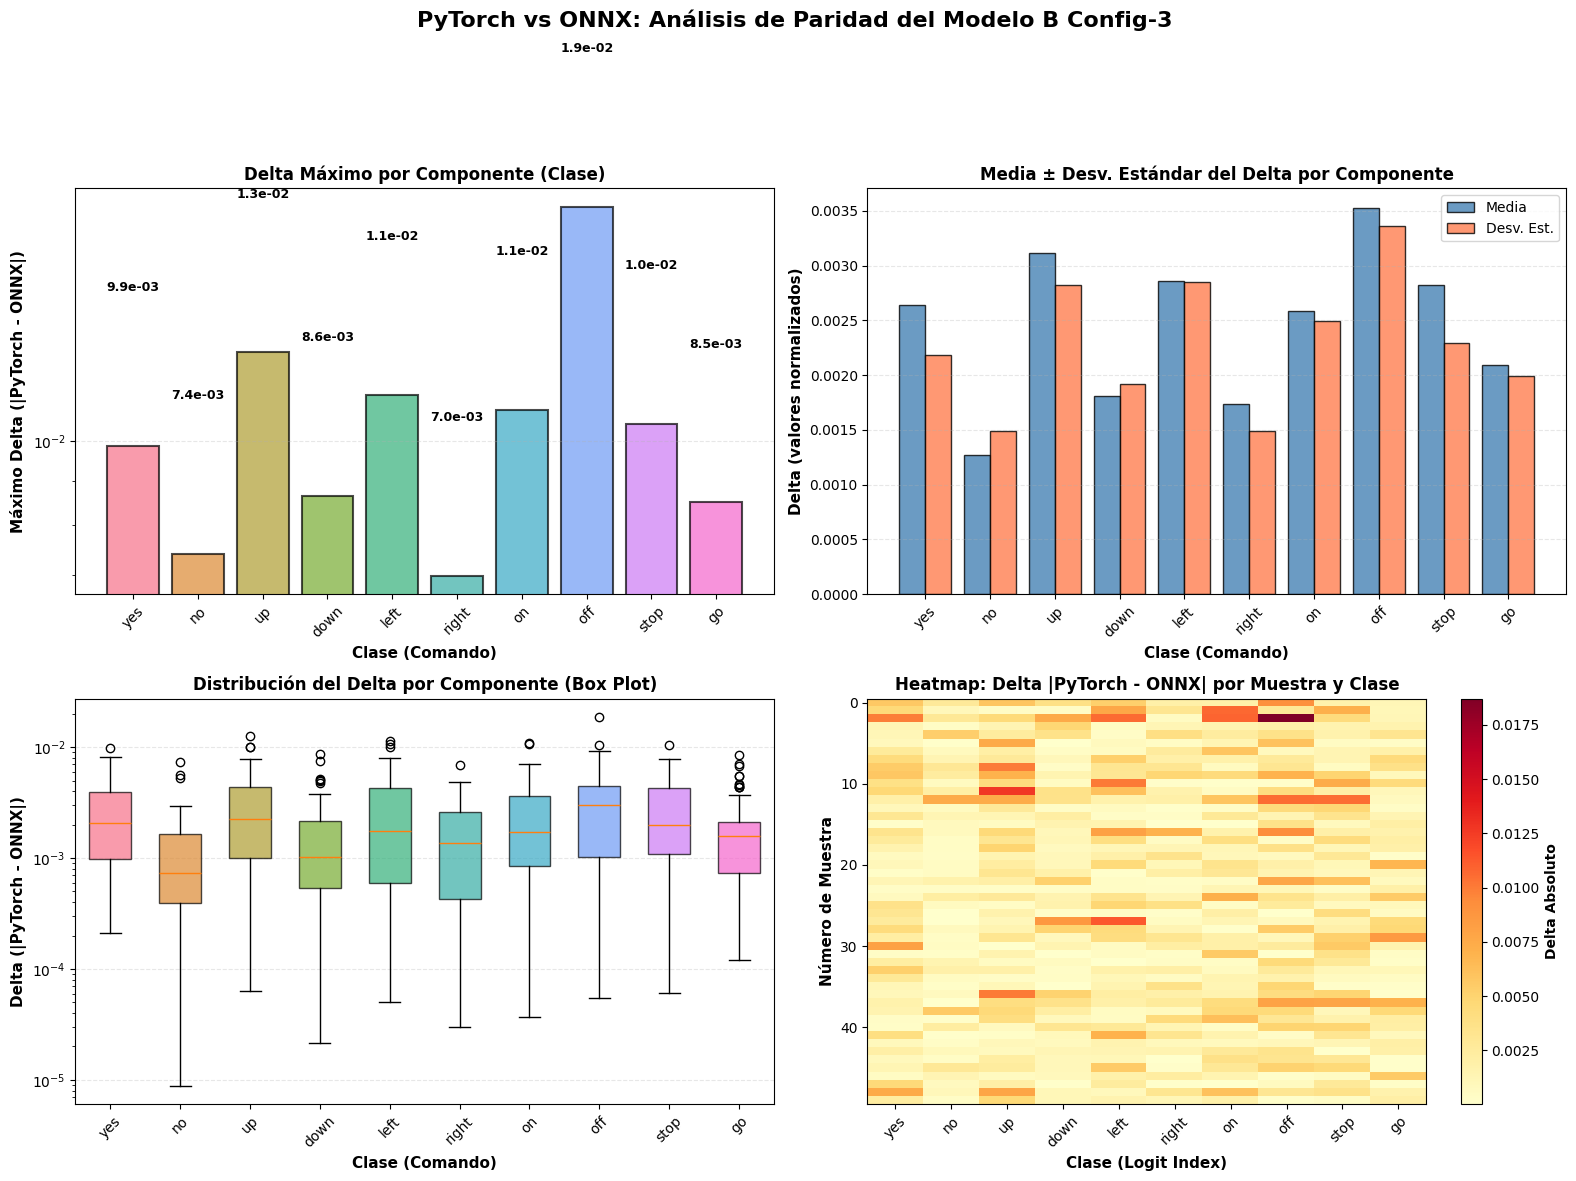


══════════════════════════════════════════════════════════════════════
Gráfica guardada en: c:\AI_Proyecto1_2026\modelos\pytorch_vs_onnx_parity.png
══════════════════════════════════════════════════════════════════════


In [6]:
import torch
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ──────────────────────────────────────────────
# CONFIGURACIÓN
# ──────────────────────────────────────────────
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
NUM_CLASSES = len(COMMANDS)
IMG_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ──────────────────────────────────────────────
# VALIDAR RUTAS
# ──────────────────────────────────────────────
base_dir = find_project_root(Path.cwd()) / "modelos"
best_model_path = base_dir / "best_model_b_raw_config3.pth"
onnx_model_path = base_dir / "modelo_b_config3.onnx"

print(f"Buscando archivos en: {base_dir}")
print(f"PyTorch model: {best_model_path.exists()}")
print(f"ONNX model:    {onnx_model_path.exists()}")

if not onnx_model_path.exists():
    print(f"\n ARCHIVO NO ENCONTRADO: {onnx_model_path}")
    print("\n SOLUCIÓN:")
    print("   1. Verifica que la celda anterior (Exportación a ONNX) se ejecutó correctamente")
    print("   2. Ejecuta nuevamente la celda anterior si es necesario")
    print("   3. Luego re-ejecuta esta celda")
    print("\n Archivos .onnx disponibles en la carpeta:")
    onnx_files = list(base_dir.glob("*.onnx"))
    if onnx_files:
        for f in onnx_files:
            print(f"   - {f.name}")
    else:
        print("   (ninguno encontrado)")
    raise FileNotFoundError(f"Archivo ONNX no existe: {onnx_model_path}")

# ──────────────────────────────────────────────
# CARGAR MODELOS
# ──────────────────────────────────────────────
print("\n Cargando modelos...")

# Cargar modelo PyTorch
model_pytorch = MobileNetV2Audio(num_classes=NUM_CLASSES)
model_pytorch.load_state_dict(torch.load(best_model_path, map_location="cpu"))
model_pytorch.eval()
model_pytorch.to(DEVICE)
print("PyTorch model cargado")

# Cargar modelo ONNX
try:
    ort_session = ort.InferenceSession(str(onnx_model_path), providers=['CPUExecutionProvider'])
    onnx_input_name = ort_session.get_inputs()[0].name
    onnx_output_name = ort_session.get_outputs()[0].name
    print("ONNX model cargado")
except Exception as e:
    print(f"Error al cargar ONNX: {e}")
    raise

# ──────────────────────────────────────────────
# GENERAR MUESTRAS DE PRUEBA
# ──────────────────────────────────────────────
num_test_samples = 50
test_inputs = torch.randn((num_test_samples, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32)
print(f"\n Generando {num_test_samples} muestras de prueba...")

# ──────────────────────────────────────────────
# INFERENCIA Y COMPARACIÓN
# ──────────────────────────────────────────────
pytorch_logits_list = []
onnx_logits_list = []
deltas = []

with torch.no_grad():
    for i in range(num_test_samples):
        # PyTorch inference
        input_pt = test_inputs[i:i+1].to(DEVICE)
        logits_pt = model_pytorch(input_pt).cpu().numpy()
        pytorch_logits_list.append(logits_pt[0])
        
        # ONNX inference
        input_onnx = test_inputs[i:i+1].numpy().astype(np.float32)
        logits_onnx = ort_session.run(
            [onnx_output_name],
            {onnx_input_name: input_onnx}
        )[0][0]
        onnx_logits_list.append(logits_onnx)
        
        # Calcular diferencia
        delta = np.abs(logits_pt[0] - logits_onnx)
        deltas.append(delta)

pytorch_logits = np.array(pytorch_logits_list)  # Shape: (num_test_samples, NUM_CLASSES)
onnx_logits = np.array(onnx_logits_list)        # Shape: (num_test_samples, NUM_CLASSES)
deltas = np.array(deltas)                       # Shape: (num_test_samples, NUM_CLASSES)

# ──────────────────────────────────────────────
# CÁLCULOS ESTADÍSTICOS
# ──────────────────────────────────────────────
max_delta_per_sample = deltas.max(axis=1)  # Máximo delta por muestra
max_delta_per_class = deltas.max(axis=0)   # Máximo delta por clase
mean_delta_per_class = deltas.mean(axis=0)  # Media delta por clase
std_delta_per_class = deltas.std(axis=0)   # Desviación estándar delta por clase

overall_max_delta = deltas.max()
overall_mean_delta = deltas.mean()

print("\n" + "═" * 70)
print("COMPARACIÓN PYTORCH VS ONNX - ANÁLISIS DE PARIDAD")
print("═" * 70)
print(f"\n Estadísticas Globales ({num_test_samples} muestras):")
print(f"  Máximo delta:     {overall_max_delta:.2e}")
print(f"  Media delta:      {overall_mean_delta:.2e}")
print(f"  Mínimo delta:     {deltas.min():.2e}")
print(f"\n Delta máximo por clase (componente):")
for i, cmd in enumerate(COMMANDS):
    print(f"  {cmd:8s}: max={max_delta_per_class[i]:.2e}, mean={mean_delta_per_class[i]:.2e} ± {std_delta_per_class[i]:.2e}")

# ──────────────────────────────────────────────
# VISUALIZACIÓN: 4 GRÁFICAS
# ──────────────────────────────────────────────
print(f"\n Generando visualizaciones...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("PyTorch vs ONNX: Análisis de Paridad del Modelo B Config-3", fontsize=16, fontweight='bold')

# Gráfica 1: Delta máximo por componente (clase)
ax = axes[0, 0]
colors_delta = sns.color_palette("husl", NUM_CLASSES)
bars1 = ax.bar(COMMANDS, max_delta_per_class, color=colors_delta, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Clase (Comando)', fontsize=11, fontweight='bold')
ax.set_ylabel('Máximo Delta (|PyTorch - ONNX|)', fontsize=11, fontweight='bold')
ax.set_title('Delta Máximo por Componente (Clase)', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)
# Agregar valores encima de las barras
for i, (bar, val) in enumerate(zip(bars1, max_delta_per_class)):
    ax.text(bar.get_x() + bar.get_width()/2, val*1.5, f'{val:.1e}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfica 2: Media y Desv. Estándar del delta por componente
ax = axes[0, 1]
x_pos = np.arange(NUM_CLASSES)
ax.bar(x_pos - 0.2, mean_delta_per_class, 0.4, label='Media', alpha=0.8, color='steelblue', edgecolor='black')
ax.bar(x_pos + 0.2, std_delta_per_class, 0.4, label='Desv. Est.', alpha=0.8, color='coral', edgecolor='black')
ax.set_xlabel('Clase (Comando)', fontsize=11, fontweight='bold')
ax.set_ylabel('Delta (valores normalizados)', fontsize=11, fontweight='bold')
ax.set_title('Media ± Desv. Estándar del Delta por Componente', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(COMMANDS, rotation=45)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Gráfica 3: Distribución del delta por muestra (Box Plot)
ax = axes[1, 0]
bp = ax.boxplot([deltas[:, i] for i in range(NUM_CLASSES)], 
                  labels=COMMANDS,
                  patch_artist=True,
                  widths=0.6)
for patch, color in zip(bp['boxes'], colors_delta):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Clase (Comando)', fontsize=11, fontweight='bold')
ax.set_ylabel('Delta (|PyTorch - ONNX|)', fontsize=11, fontweight='bold')
ax.set_title('Distribución del Delta por Componente (Box Plot)', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# Gráfica 4: Mapa de calor del delta total por muestra y clase
ax = axes[1, 1]
im = ax.imshow(deltas, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Clase (Logit Index)', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Muestra', fontsize=11, fontweight='bold')
ax.set_title('Heatmap: Delta |PyTorch - ONNX| por Muestra y Clase', fontsize=12, fontweight='bold')
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(COMMANDS, rotation=45)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Delta Absoluto', fontsize=10, fontweight='bold')

plt.tight_layout()
output_path = base_dir / "pytorch_vs_onnx_parity.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "═" * 70)
print(f"Gráfica guardada en: {output_path}")
print("═" * 70)

# Comparación de Paridad: PyTorch vs ONNX
Validación de la consistencia entre el modelo PyTorch y su versión exportada en ONNX. Se compara el error por componente (logits) y el máximo delta observado.